In [1]:
import numpy as np
import matplotlib.pyplot as plt


# Task 21: Manual Convolution

Before using `Conv2D`, implement the convolution operation manually using NumPy.

1. Implement `make_square_image(size=28)`. The function returns a black 28×28 image with a white square centered in the middle.
2. Implement `conv2d(image, kernel, stride, padding)` that slides the filter over the image and computes the sum of element-wise products. Use only NumPy without any built-in convolution routines.
3. Define a dictionary of 3×3 filters: `vertical_edge`, `horizontal_edge`, `blur`, and `sharpen`.
4. Implement `plot_images(images, titles)` to display the original input image side-by-side with the output of each filter.
5. Verify the output shape across four combinations: padding of 0 or 1, and stride of 1 or 2.

### Questions to answer:
- What is the general formula for the output dimensions?
- What feature does each filter detect?
- Why does the `vertical_edge` output contain both positive and negative values?

1. Implement `make_square_image(size=28)`. The function returns a black 28×28 image with a white square centered in the middle.


In [2]:
def make_square_image(size=28):
    img = np.zeros((size, size))      # black image: size x size array of zeros

    s = 12                            # side length of the white square
    start = (size - s) // 2           # index where the square begins
                                      # (equal black margin on both sides)

    img[start:start + s, start:start + s] = 1

    return img 

2. Implement `conv2d(image, kernel, stride, padding)` that slides the filter over the image and computes the sum of element-wise products. Use only NumPy without any built-in convolution routines.

In [3]:
def conv2d(image, kernel, stride=1, padding=0):
    # step 1: add a frame of zeros around the image (padding=0 -> no change)
    image = np.pad(image, padding)

    # step 2: size of the output
    k = kernel.shape[0]                              # kernel size (e.g. 3)
    out_h = (image.shape[0] - k) // stride + 1       # how many windows fit vertically
    out_w = (image.shape[1] - k) // stride + 1       # how many windows fit horizontally

    # step 3: empty output, we will fill it cell by cell
    result = np.zeros((out_h, out_w))

    # step 4: slide the window over the image
    for i in range(out_h):                           # i = row index of the output
        for j in range(out_w):                       # j = column index of the output
            top = i * stride                         # first row of the window in the image
            left = j * stride                        # first column of the window in the image

            # cut a k x k piece of the image (the current window)
            window = image[top:top + k, left:left + k]

            # multiply window and kernel cell by cell, sum everything into one number
            result[i, j] = np.sum(window * kernel)

    # step 5: return the finished output (feature map)
    return result

In [4]:
img = np.array([[1,1,1,0,0]] * 5)
flt = np.array([[1,0,-1]] * 3)
print(conv2d(img, flt))

[[0. 3. 3.]
 [0. 3. 3.]
 [0. 3. 3.]]


3. Define a dictionary of 3×3 filters: `vertical_edge`, `horizontal_edge`, `blur`, and `sharpen`.

In [5]:
filters = {
    # compares left column with right column -> reacts to vertical edges
    "vertical_edge": np.array([[1, 0, -1],
                               [1, 0, -1],
                               [1, 0, -1]]),

    # compares top row with bottom row -> reacts to horizontal edges
    # (same as vertical_edge, just transposed)
    "horizontal_edge": np.array([[ 1,  1,  1],
                                 [ 0,  0,  0],
                                 [-1, -1, -1]]),

    # average of 9 neighbours: 9 equal weights of 1/9, sum = 1
    "blur": np.ones((3, 3)) / 9,

    # boosts the centre pixel, subtracts the 4 direct neighbours, sum = 1
    "sharpen": np.array([[ 0, -1,  0],
                         [-1,  5, -1],
                         [ 0, -1,  0]]),
}

In [6]:
for name, f in filters.items():
    print(name, f.sum())

vertical_edge 0
horizontal_edge 0
blur 1.0
sharpen 1


4. Implement `plot_images(images, titles)` to display the original input image side-by-side with the output of each filter.

In [7]:
def plot_images(images, titles):
    n = len(images)                                   # how many images to show

    # one row with n slots side by side
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))

    for ax, img, title in zip(axes, images, titles):  # go through slots, images, titles together
        ax.imshow(img, cmap="gray")                   # draw the 2D array as a grayscale image
        ax.set_title(title)                           # name above the image
        ax.axis("off")                                # hide the axis numbers

    plt.tight_layout()                                # avoid overlapping titles
    plt.show()

5. Verify the output shape across four combinations: padding of 0 or 1, and stride of 1 or 2.

In [8]:
img = make_square_image()
flt = filters["vertical_edge"]

for p in (0, 1):                       # padding values
    for s in (1, 2):                   # stride values
        out = conv2d(img, flt, stride=s, padding=p)
        print(f"padding={p}, stride={s} -> shape {out.shape}")

padding=0, stride=1 -> shape (26, 26)
padding=0, stride=2 -> shape (13, 13)
padding=1, stride=1 -> shape (28, 28)
padding=1, stride=2 -> shape (14, 14)


(28 + 0(2*padding) -3(filtr)) //1(stride) + 1 = 26

(28 + 0(2*padding) -3(filtr)) //2(stride) + 1 = 13

(28 + 2(2*padding) -3(filtr)) //1(stride) + 1 = 28

(28 + 2(2*padding) -3(filtr)) //2(stride) + 1 = 14

### Questions to answer:
- What is the general formula for the output dimensions?
- What feature does each filter detect?

1. The output size is (n + 2p − k) // s + 1, where n is the input size, p is the padding, k is the kernel size and s is the stride. We add the padding to both sides of the input (hence 2p), subtract the kernel size (because the window has to fit inside the image), divide by the stride and round down, and then add 1 (for the first window position).
2.
  vertical edge   -> finds vertical edges (left-right brightness change)
  
  horizontal edge -> finds horizontal edges (top-bottom brightness change)
  
  blur            -> smooths the image by averaging neighbors, reduces noise
  
  sharpen         -> amplifies differences from neighbors, makes details crisper

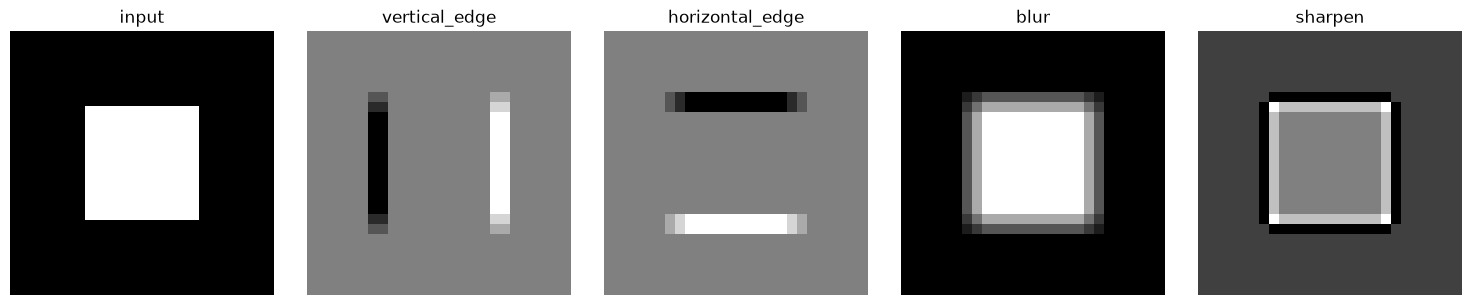

In [9]:
2. 
img = make_square_image()

images = [img]
titles = ["input"]
for name, f in filters.items():
    images.append(conv2d(img, f))
    titles.append(name)

plot_images(images, titles)

# Task 22: The Conv2D Layer and Its Parameters

The exact same operation, but now executed by a neural network layer.

- Build a model with a single layer: `Conv2D` with 1 filter of size 3×3, no activation function, accepting an input image of shape `28×28×1`.
- Call `summary()` (or calculate parameters manually in PyTorch) and record the parameter count.
- Change the number of filters to 8, and then additionally increase the number of input channels to 3. Record the parameter count for each configuration.
- Manually assign the `vertical_edge` weights and a bias of 0 to the layer. Compare the layer's output with your custom `conv2d` function from Task 21 using `np.allclose`.
- Compare the output shapes for `padding='valid'` versus `padding='same'` (in PyTorch, these correspond to `padding=0` and `padding=1`).

### Questions to answer:
- Where do these parameter counts come from?
- Why is the parameter count independent of the image resolution/size?
- How many parameters would a `Dense` layer have if it mapped 784 input pixels to 784 output values?

Build a model with a single layer: `Conv2D` with 1 filter of size 3×3, no activation function, accepting an input image of shape `28×28×1`.

Call `summary()` (or calculate parameters manually in PyTorch) and record the parameter count.

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D
from tensorflow.keras.layers import MaxPooling2D

In [20]:
Model_1 = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(filters=1, kernel_size=(3, 3))
    ])
Model_1.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 1)      │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10 (40.00 B)

 Trainable params: 10 (40.00 B)

 Non-trainable params: 0 (0.00 B)

 1 filter,  1 input channel  -> 10 params   (3* 3 * 1 weights + 1 bias)


- Change the number of filters to 8, and then additionally increase the number of input channels to 3. Record the parameter count for each configuration.

In [17]:
Model_2 = Sequential([
    Input(shape=(28, 28, 3)),
    Conv2D(filters=8, kernel_size=(3,3))
    ])
Model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 8)      │           224 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 224 (896.00 B)

 Trainable params: 224 (896.00 B)

 Non-trainable params: 0 (0.00 B)

8 filters, 3 input channels -> 224 params  (8 * (3 * 3 * 3 + 1))


- Manually assign the `vertical_edge` weights and a bias of 0 to the layer. Compare the layer's output with your custom `conv2d` function from Task 21 using `np.allclose`.

In [23]:
vertical_edge = np.array([[1, 0, -1],
                          [1, 0, -1],
                          [1, 0, -1]], dtype=np.float32)

# 1. layer with random weights
Model_3 = Sequential([Input(shape=(10, 10, 1)), Conv2D(1, (3, 3))])

# 2. set the weights by hand
# Keras weight shape is (kernel_h, kernel_w, in_channels, filters) = (3, 3, 1, 1)
# bias shape is (filters,) = (1,)
Model_3.layers[0].set_weights([vertical_edge.reshape(3, 3, 1, 1), np.zeros(1)])

# 3. run the same image through both
image = np.random.rand(10, 10).astype(np.float32)

keras_out = Model_3.predict(image.reshape(1, 10, 10, 1))   # input needs shape (batch, H, W, channels)
keras_out = keras_out.reshape(8, 8)                      # drop batch and channel dims -> (8, 8)

my_out = conv2d(image, vertical_edge)                    # your function from Task 21

# 4. compare
print(np.allclose(keras_out, my_out))                    # expected: True

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step
True


 Summary:
 We build a Keras Conv2D layer (1 filter, 3x3) for a 10x10 grayscale image and replace its
 
 random starting weights with the vertical-edge kernel and a bias of 0.
 
 Then we run the same random image through the Keras layer and through our own
 
 conv2d function from Task 21, and compare the two outputs with np.allclose.
 
 If they match, it proves that a Conv2D layer is just a filter sliding over the image,
 
 the same operation we implemented by hand. The only difference is that in a real network
 
 the filter values are learned during training instead of being set manually.

- Compare the output shapes for `padding='valid'` versus `padding='same'` (in PyTorch, these correspond to `padding=0` and `padding=1`)

In [26]:
model_valid = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(1, (3, 3), padding="valid")
])

model_same = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(1, (3, 3), padding="same")
])

print(model_valid.output_shape)
print(model_same.output_shape)

(None, 26, 26, 1)
(None, 28, 28, 1)


 padding="valid": no padding, the filter stays inside the image, so the output shrinks: 28 - 3 + 1 = 26 -> output shape (26, 26, 1)
 
padding="same": a border of zeros is added around the image,so the output keeps the input size: 28 -> output shape (28, 28, 1)
 
The parameter count is the same in both cases (10 = 3*3 weights + 1 bias),because padding changes how the filter slides, not the filter itself.

- Where do these parameter counts come from?
- Why is the parameter count independent of the image resolution/size?
- How many parameters would a `Dense` layer have if it mapped 784 input pixels to 784 output values?

1. They come from the formula:
       params = (kernel_height * kernel_width * input_channels + 1) * num_filters
   Each filter has kernel_height * kernel_width weights for every input channel,
   plus 1 bias. This is repeated for every filter.
   - 1 filter,  1 channel:   (3 * 3 * 1 + 1) * 1 = 10
   - 8 filters, 1 channel:   (3 * 3 * 1 + 1) * 8 = 80
   - 8 filters, 3 channels:  (3 * 3 * 3 + 1) * 8 = 224


2. Because the same small filter (here 3x3 = 9 weights) slides over the whole image.
   The weights are shared across all positions, so a 1000x1000 image and a 28x28 image
   use exactly the same number of parameters. Only the size of the output changes,
   not the number of weights.


3. Every input is connected to every output with its own weight, and each output
   neuron has one bias:
       784 * 784 + 784 = 614,656 + 784 = 615,440 parameters
   That is over 60,000 times more than Conv2D(1, (3, 3)), which has only 10.

# Task 23: Pooling and Shape Tracking

Observe how the image transforms as it passes through sequential layers.

- Implement `pool2d(image, size, mode)` in NumPy supporting `"max"` and `"avg"` modes. Apply it to the `vertical_edge` output from Task 21 and plot both resulting images side-by-side.
- Build the following model architecture: `Conv2D(8, (3, 3), activation='relu')` → `MaxPooling2D(2)` → `Conv2D(16, (3, 3), activation='relu')` → `MaxPooling2D(2)` → `Flatten` → `Dense(10)`.
- Implement `print_layer_shapes(model)` to display the output shape and parameter count for each layer.
- Calculate all output shapes on paper before executing the code, then verify against the model summary.
- For comparison, construct an MLP baseline: `Flatten` → `Dense(64)` → `Dense(10)`, and compare the total parameter count between both architectures.

### Questions to answer:
- How many parameters does a pooling layer have and why?
- What is the difference between max pooling and average pooling?
- Why does the CNN have significantly fewer parameters here than the MLP?

- Implement `pool2d(image, size, mode)` in NumPy supporting `"max"` and `"avg"` modes. Apply it to the `vertical_edge` output from Task 21 and plot both resulting images side-by-side.

In [47]:
from tensorflow.keras.layers import Dense, Flatten

def pool2d(image, size, mode):
    """Non-overlapping pooling with a size x size window. mode: 'max' or 'avg'."""
    h, w = image.shape
    out_h = h // size
    out_w = w // size
    output = np.zeros((out_h, out_w))
    
    for i in range(out_h):                                          # every output row
        for j in range(out_w):                                      # every output column
            window = image[i*size:(i+1)*size, j*size:(j+1)*size]    # cut one size x size block
            output[i, j] = window.max()                             # for now only max

    return output

In [48]:
test = np.array([[1, 3, 2, 0],
                 [5, 2, 1, 4],
                 [0, 1, 7, 8],
                 [2, 6, 3, 5]])
print(pool2d(test, 2, "max"))

[[5. 4.]
 [6. 8.]]


- Build the following model architecture: `Conv2D(8, (3, 3), activation='relu')` → `MaxPooling2D(2)` → `Conv2D(16, (3, 3), activation='relu')` → `MaxPooling2D(2)` → `Flatten` → `Dense(10)`.

In [50]:
Model_4 = Sequential([
    Input(shape=(28, 28, 3)),
    Conv2D(filters=8, kernel_size=(3,3), activation='relu'),
    MaxPooling2D(2),
    Conv2D(filters=16, kernel_size=(3,3), activation='relu'),
    MaxPooling2D(2),
    Flatten(),
    Dense(10)
    ])
Model_4.summary()
Model_4.out

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 26, 26, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 11, 11, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         4,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,402 (21.10 KB)

 Trainable params: 5,402 (21.10 KB)

 Non-trainable params: 0 (0.00 B)

- Implement `print_layer_shapes(model)` to display the output shape and parameter count for each layer.


In [55]:
def print_layer_shapes(model):
    
    for layer in model.layers:

        print(f"{layer.name}{str(layer.output.shape)} num of params: {layer.count_params()} \n")
        
        
print_layer_shapes(Model_4)

conv2d_10(None, 26, 26, 8) num of params: 224 

max_pooling2d_2(None, 13, 13, 8) num of params: 0 

conv2d_11(None, 11, 11, 16) num of params: 1168 

max_pooling2d_3(None, 5, 5, 16) num of params: 0 

flatten_1(None, 400) num of params: 0 

dense_1(None, 10) num of params: 4010 



(3 * 3 * 3 + 1) * 8 = 224 

(3 * 3 * 8 + 1) * 16 = 1168

5 * 5 * 16 = 400

400 * 10 + 10 = 4010 

TOGETHER = 5402


For comparison, construct an MLP baseline: `Flatten` → `Dense(64)` → `Dense(10)`, and compare the total parameter count between both architectures.

In [57]:
Model_5 = Sequential([
    Input(shape=(28, 28, 3)),
    Conv2D(filters=8, kernel_size=(3,3), activation='relu'),
    MaxPooling2D(2),
    Conv2D(filters=16, kernel_size=(3,3), activation='relu'),
    MaxPooling2D(2),
    Flatten(),
    Dense(64),
    Dense(10)
    ])
Model_5.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 26, 26, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 11, 11, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        25,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,706 (108.23 KB)

 Trainable params: 27,706 (108.23 KB)

 Non-trainable params: 0 (0.00 B)

Comparison between two models 

In [60]:
print("First model \n\n")
print_layer_shapes(Model_4)

print("Second model \n\n")

print_layer_shapes(Model_5)

First model 


conv2d_10(None, 26, 26, 8) num of params: 224 

max_pooling2d_2(None, 13, 13, 8) num of params: 0 

conv2d_11(None, 11, 11, 16) num of params: 1168 

max_pooling2d_3(None, 5, 5, 16) num of params: 0 

flatten_1(None, 400) num of params: 0 

dense_1(None, 10) num of params: 4010 

Second model 


conv2d_14(None, 26, 26, 8) num of params: 224 

max_pooling2d_6(None, 13, 13, 8) num of params: 0 

conv2d_15(None, 11, 11, 16) num of params: 1168 

max_pooling2d_7(None, 5, 5, 16) num of params: 0 

flatten_3(None, 400) num of params: 0 

dense_4(None, 64) num of params: 25664 

dense_5(None, 10) num of params: 650 



(3 * 3 * 3 + 1) * 8 = 224 

(3 * 3 * 8 + 1) * 16 = 1168

5 * 5 * 16 = 400

400 * 64 + 64 = 25664 + 650 

TOGETHER = 27706


- How many parameters does a pooling layer have and why?
- What is the difference between max pooling and average pooling?
- Why does the CNN have significantly fewer parameters here than the MLP?

1. Zero. Pooling applies a fixed rule (take the max or the mean of each window),
   so it has no weights or biases to learn. It only reduces the height and width
   of the feature maps (e.g. size 2 halves each dimension).
       
2. Max pooling keeps the strongest value in each window, so it preserves the
   presence of a detected feature (e.g. an edge). Average pooling keeps the mean
   of the window, so it smooths the image and dilutes strong local activations.

3. Because of weight sharing: the same small filter is reused over the whole image,
   so the parameter count does not grow with image size. Pooling also shrinks the
   feature maps before the Dense layer. In an MLP every input pixel is connected to
   every neuron with its own weight, so the number of parameters explodes
   (e.g. a single Dense(10) on 28x28x3 pixels already has 23,530 parameters,
   more than the whole CNN with 5,402).

# Task 24: First CNN Training

The network learns to distinguish between horizontal and vertical lines.

- Implement `generate_lines_data(n_samples, size, region, noise, seed)`. Each sample consists of random background noise plus a single line with a random length (8–12 px) placed at an arbitrary position. Class 0 corresponds to a horizontal line; Class 1 corresponds to a vertical line. The `region` parameter accepts `"full"`, `"left"`, or `"right"` to designate the line placement area (use `"full"` for now).
- Visualize a grid showing a few representative examples of each class.
- Implement `build_mlp(hidden_units)` and `build_cnn(filters, pooling)`. `filters` is a list, e.g., `[8, 16]`, where every `Conv2D` layer is followed by `MaxPooling(2)`. The `pooling` parameter accepts `"flatten"` or `"global"`. Output layer: 1 neuron (`sigmoid` in Keras, raw logits with `BCEWithLogitsLoss` in PyTorch).
- Implement `train_model(...)` that returns the training history as a dictionary with keys: `loss`, `val_loss`, `accuracy`, and `val_accuracy`. In PyTorch, write the training loop manually, but keep the return format identical so that `plot_history` works across both frameworks.
- Train the MLP `[64]` and the CNN `[8, 16]` with `"flatten"` for 10 epochs. Plot the training curves and compile a comparison table containing: total parameter count and test accuracy.

### Questions to answer:
- Was the CNN significantly better than the MLP?
- If both models achieve similar accuracy, what structural advantage does the CNN still maintain?

Implement `generate_lines_data(n_samples, size, region, noise, seed)`. Each sample consists of random background noise plus a single line with a random length (8–12 px) placed at an arbitrary position. Class 0 corresponds to a horizontal line; Class 1 corresponds to a vertical line. The `region` parameter accepts `"full"`, `"left"`, or `"right"` to designate the line placement area (use `"full"` for now).

example

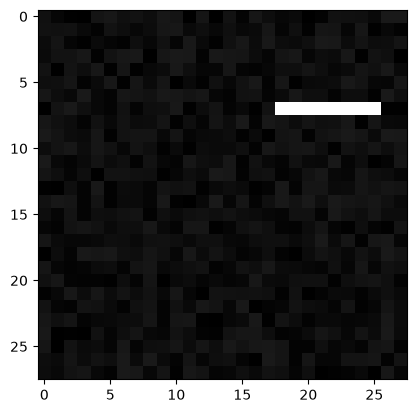

In [66]:
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
size = 28
img = 0.1 * rng.random((size, size))      # one noisy image

L = rng.integers(8, 13)                   # line length: 8..12
r = rng.integers(0, size)                 # row of the line
c = rng.integers(0, size - L + 1)         # start column (the line must fit in the image)

img[r, c:c+L] = 1.0                       # horizontal line: one row, L columns

plt.imshow(img, cmap="gray")
plt.show()

In [75]:
def generate_lines_data(n_samples, size=28, region="full", noise=0.1, seed=0):
    """Images with background noise and one line. Class 0 = horizontal, class 1 = vertical."""
    rng = np.random.default_rng(seed)
    X = noise * rng.random((n_samples, size, size))      # noisy background
    y = rng.integers(0, 2, n_samples)                    # random class (0/1) for every image

    for i in range(n_samples):                           # draw one line in every image
        L = rng.integers(8, 13)                          # line length: 8..12
        r = rng.integers(0, size)                        # row (horizontal) or column (vertical)
        c = rng.integers(0, size - L + 1)                # where the line starts
        if y[i] == 0:
            X[i, r, c:c+L] = 1.0                         # horizontal line
        else:
            X[i, c:c+L, r] = 1.0                         # vertical line

    X = X[..., np.newaxis]                               # (n, size, size) -> (n, size, size, 1)
    return X, y

In [81]:
X, y = generate_lines_data(200)
X.shape
X[0].shape

(28, 28, 1)

- Visualize a grid showing a few representative examples of each class.

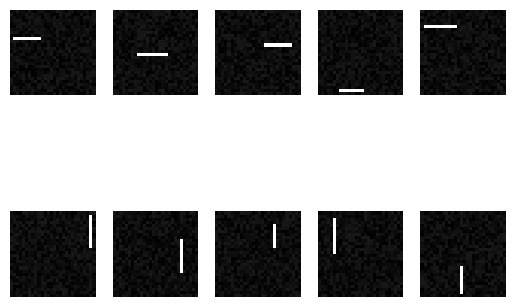

In [85]:
fig, axes = plt.subplots(2, 5)

# row 0: class 0
imgs0 = X[y == 0][:5]
for k in range(5):
    axes[0, k].imshow(imgs0[k, :, :, 0], cmap="gray")
    axes[0, k].axis("off")

# row 1: class 1
imgs1 = X[y == 1][:5]
for k in range(5):
    axes[1, k].imshow(imgs1[k, :, :, 0], cmap="gray")
    axes[1, k].axis("off")

plt.show()